# Stock analysis of S&P 500, Nikkei 225 and FTSE 100

### Libraries

In [1]:
import pandas as pd
import yfinance as yf
from yahooquery import Ticker
import matplotlib.pyplot as plt
from datetime import datetime
import time
import json
import pydeck as pdk
from geopy.geocoders import Nominatim

### Ticker Lists

Selected companies listed in S&P500, FTSE100 and Nikkei225

In [2]:
# Generated by Gemini
sp500 = [
        "MSFT", "AAPL", "NVDA", "AMZN", "GOOGL", "GOOG", "META", "BRK-B", "LLY", "AVGO",
        "V", "TSLA", "JPM", "WMT", "UNH", "MA", "XOM", "HD", "PG", "ORCL",
        "COST", "JNJ", "NFLX", "AMD", "MRK", "ABBV", "CRM", "BAC", "PEP", "ADBE",
        "KO", "CVX", "TMO", "ACN", "WFC", "CSCO", "QCOM", "LIN", "MCD", "GE",
        "INTU", "DIS", "INTC", "CAT", "TXN", "VZ", "AMGN", "IBM", "CMCSA", "AXP",
        "MMM", "ABT", "ACGL", "ADSK", "AEE", "AEP", "AES", "AFL", "A", "AGCO",
        "AIG", "AIZ", "AJG", "AKAM", "ALB", "ALGN", "ALK", "ALL", "ALLE", "ALXN",
        "AMCR", "AME", "AMP", "AMT", "AON", "AOS", "APA", "APD", "APH", "APTV",
        "ARE", "ATO", "ATVI", "AVB", "AVY", "AWK", "AZO", "BA", "BALL", "BAX",
        "BBY", "BDX", "BEN", "BF-B", "BG", "BIIB", "BIO", "BK", "BKNG", "BKR",
        "BLDR", "BLK", "BLL", "BMY", "BR", "BRO", "BSX", "BWA", "BXP", "C",
        "CAG", "CAH", "CARR", "CAT", "CBOE", "CBRE", "CCI", "CCK", "CCL", "CDAY",
        "CDNS", "CDW", "CE", "CEG", "CF", "CFG", "CHD", "CHRW", "CHTR", "CI",
        "CINF", "CL", "CLX", "CMA", "CMG", "CMI", "CMS", "CNC", "CNP", "COF",
        "COO", "COP", "COR", "COV", "CPB", "CPIE", "CPRT", "CPT", "CRL", "CRM",
        "CRWD", "CSGP", "CSX", "CTAS", "CTLT", "CTRA", "CTSH", "CTVA", "CZR", "D",
        "DAL", "DD", "DE", "DFS", "DG", "DGX", "DHI", "DHR", "DISH", "DLR",
        "DLTR", "DOV", "DOW", "DPZ", "DRI", "DTE", "DUK", "DVA", "DVN", "DXC",
        "DXCM", "EA", "EBAY", "ECL", "ED", "EFX", "EG", "EIX", "EL", "ELV",
        "EMN", "EMR", "ENPH", "EOG", "EPAM", "EQIX", "EQR", "EQT", "ES", "ESS",
        "ETN", "ETR", "ETSY", "EVRG", "EW", "EXC", "EXPD", "EXPE", "EXR", "F",
        "FANG", "FAST", "FBHS", "FCX", "FDS", "FDX", "FE", "FFIV", "FI", "Fiserv",
        "FITB", "FLT", "FMC", "FOXA", "FOX", "FRC", "FRT", "FSLR", "FTNT", "FTV",
        "GD", "GDDY", "GEHC", "GEN", "GILD", "GIS", "GL", "GLW", "GM", "GNRC",
        "GPC", "GPN", "GRMN", "GS", "GWRE", "HAL", "HAS", "HBAN", "HCA", "PEAK",
        "HCP", "HES", "HIG", "HII", "HLT", "HOLX", "HON", "HPE", "HPQ", "HRL",
        "HSIC", "HST", "HSY", "HUBB", "HUM", "HWM", "HZNP", "ICE", "IDXX", "IEX",
        "IFF", "ILMN", "INCY", "INVH", "IP", "IPG", "IQV", "IR", "IRM", "ISRG",
        "IT", "ITW", "IVZ", "J", "JBHT", "JCI", "JKHY", "JNJ", "JNPR", "K",
        "KDP", "KEY", "KEYS", "KG", "KHC", "KIM", "KLAC", "KMB", "KMI", "KMX",
        "KNX", "KRE", "KSS", "KSU", "KVUE", "L", "LDOS", "LEN", "LH", "LHX",
        "LIN", "LKQ", "LLY", "LMT", "LNC", "LNT", "LOW", "LRCX", "LUMN", "LUV",
        "LVS", "LW", "LYB", "LYV", "MAA", "MAR", "MAS", "MCK", "MCHP", "MCK",
        "MCO", "MDLZ", "MDT", "MET", "META", "MGM", "MHK", "MI", "MKTX", "MLM",
        "MMC", "MNST", "MO", "MOH", "MOS", "MPC", "MPWR", "MRNA", "MRK", "MRO",
        "MS", "MSI", "MTB", "MTD", "MU", "NATH", "NCLH", "NDAQ", "NDSN", "NEE",
        "NEM", "NEU", "NFLX", "NI", "NKE", "NLOK", "NLSN", "NOC", "NOW", "NRG",
        "NSC", "NTAP", "NTRS", "NUE", "NVDA", "NVR", "NWL", "NWS", "NWSA", "NXPI",
        "O", "ODFL", "OGN", "OI", "OKE", "OMC", "ON", "ORLY", "OTIS", "OXY",
        "PANW", "PARA", "PAYC", "PAYX", "PBCT", "PCAR", "PCG", "PEAK", "PEG", "PENN",
        "PEP", "PFE", "PFG", "PG", "PGR", "PH", "PHM", "PKG", "PKI", "PLD",
        "PRU", "PSA", "PSTG", "PSX", "PTC", "PVH", "PWR", "PXD", "PYPL", "QCOM",
        "QRVO", "RCL", "RE", "REG", "REGN", "RF", "RHI", "RJM", "RL", "RMD",
        "ROK", "ROL", "ROP", "ROST", "RSG", "RTX", "SBAC", "SBUX", "SCG", "SCHW",
        "SEDG", "SEE", "SHW", "SIRI", "SIVB", "SJM", "SLB", "SLG", "SNA", "SNPS",
        "SO", "SPG", "SPGI", "SPLK", "SRE", "STE", "STT", "STX", "STZ", "SWK",
        "SWKS", "SYF", "SYK", "SYY", "T", "TAP", "TDG", "TDY", "TECH", "TEL",
        "TER", "TFC", "TFX", "TGT", "TJX", "TMO", "TMUS", "TPR", "TRGP", "TRMB",
        "TROW", "TRV", "TSCO", "TSN", "TSLA", "TT", "TTWO", "TWTR", "TXN", "TXT",
        "TYL", "UA", "UAA", "UAL", "UDR", "UHS", "ULTA", "UNM", "UNP", "UPS",
        "URI", "USB", "V", "VALE", "VFC", "VIAC", "VLO", "VMC", "VNO", "VNT",
        "VRSK", "VRSN", "VRTX", "VTR", "VTRS", "VU", "VZ", "WAB", "WAT", "WBA",
        "WBD", "WEC", "WELL", "WFC", "WHR", "WM", "WMB", "WMT", "WRB", "WRK",
        "WST", "WTW", "WY", "WYNN", "XCEL", "XLNX", "XOM", "XRAY", "XYL", "YUM",
        "ZBH", "ZBRA", "ZION", "ZTS"
    ]

In [3]:
# Generated by ChatGPT
ftse100 = [
    "AZN.L","SHEL.L","HSBA.L","ULVR.L","BP.L","GSK.L","RIO.L","GLEN.L","DGE.L","BATS.L",
    "LSEG.L","REL.L","NG.L","VOD.L","BARC.L","LLOY.L","NWG.L","STAN.L","PRU.L","AV.L",
    "CPG.L","IMB.L","TSCO.L","SBRY.L","MKS.L","AAL.L","BA.L","RR.L","SMIN.L","WEIR.L",
    "SPX.L","CRH.L","FERG.L","HLMA.L","EXPN.L","INF.L","SGE.L","AUTO.L","RS1.L","DCC.L",
    "BNZL.L","WTB.L","IHG.L","ENT.L","FLTR.L","EZJ.L","RTO.L","SMT.L","III.L","ABDN.L",
    "BLND.L","LAND.L","KGF.L","PSN.L","TW.L","BDEV.L","SGRO.L","UTG.L","SVT.L","UU.L",
    "SEV.L","CNA.L","SSE.L","NG..L","ITRK.L","ICP.L","MNDI.L","DSCT.L","HIK.L","SN.L",
    "JD.L","WPP.L","BT.A.L","PHNX.L","STJ.L","ASHM.L","ADM.L","NXT.L","CCH.L","DPLM.L",
    "PSON.L","RMV.L","SGC.L","OSB.L","INDV.L","BC.L","HWDN.L","FRAS.L","BME.L","HARL.L",
    "CTEC.L","TRN.L","BKG.L","PSH.L","FCIT.L","EDV.L","PIN.L","RKT.L","BYG.L","DRX.L"
]

In [4]:
# Generated by ChatGPT
nikkei225 = [
    "1332.T","1333.T","1605.T","1721.T","1801.T","1802.T","1803.T","1808.T","1812.T","1925.T",
    "1928.T","1963.T","2002.T","2269.T","2282.T","2413.T","2432.T","2501.T","2502.T","2503.T",
    "2768.T","2801.T","2802.T","2871.T","2914.T","3086.T","3099.T","3101.T","3103.T","3105.T",
    "3289.T","3382.T","3401.T","3402.T","3405.T","3407.T","3436.T","3659.T","3861.T","3863.T",
    "4004.T","4005.T","4021.T","4042.T","4043.T","4061.T","4063.T","4151.T","4183.T","4188.T",
    "4208.T","4272.T","4324.T","4452.T","4502.T","4503.T","4506.T","4507.T","4519.T","4523.T",
    "4543.T","4568.T","4578.T","4631.T","4689.T","4704.T","4751.T","4755.T","4901.T","4902.T",
    "4911.T","5019.T","5020.T","5101.T","5108.T","5201.T","5202.T","5214.T","5233.T","5301.T",
    "5332.T","5333.T","5401.T","5406.T","5411.T","5541.T","5631.T","5703.T","5706.T","5707.T",
    "5711.T","5713.T","5714.T","5801.T","5802.T","5803.T","5901.T","6098.T","6103.T","6113.T",
    "6178.T","6301.T","6302.T","6305.T","6326.T","6361.T","6367.T","6471.T","6472.T","6473.T",
    "6479.T","6501.T","6503.T","6504.T","6506.T","6645.T","6674.T","6701.T","6702.T","6703.T",
    "6724.T","6752.T","6753.T","6758.T","6762.T","6770.T","6841.T","6857.T","6902.T","6952.T",
    "6954.T","6971.T","6976.T","6981.T","6988.T","7003.T","7004.T","7011.T","7012.T","7013.T",
    "7186.T","7201.T","7202.T","7203.T","7205.T","7211.T","7261.T","7267.T","7269.T","7270.T",
    "7272.T","7731.T","7733.T","7735.T","7751.T","7752.T","7762.T","7832.T","7911.T","7912.T",
    "7951.T","8001.T","8002.T","8015.T","8031.T","8035.T","8053.T","8058.T","8233.T","8252.T",
    "8253.T","8267.T","8303.T","8304.T","8306.T","8308.T","8309.T","8316.T","8331.T","8354.T",
    "8355.T","8411.T","8601.T","8604.T","8628.T","8630.T","8697.T","8725.T","8750.T","8766.T",
    "8795.T","8801.T","8802.T","8804.T","8830.T","9001.T","9005.T","9007.T","9008.T","9009.T",
    "9020.T","9021.T","9022.T","9062.T","9064.T","9101.T","9104.T","9107.T","9142.T","9143.T",
    "9201.T","9202.T","9301.T","9412.T","9432.T","9433.T","9434.T","9501.T","9502.T","9503.T",
    "9531.T","9532.T","9602.T","9613.T","9735.T","9766.T","9983.T","9984.T"
]

### Exploratory Data Analysis and identifying key variables

In [33]:
sample_IBM_detail = Ticker('IBM').summary_detail
sample_IBM_quote = Ticker('IBM').quote_type
sample_IBM_profile = Ticker('IBM').asset_profile

yahooquery provides various numerical data from 'summary_detail' function. The data contains 'marketCap' and 'dividedYield'. Afterwards, extract these data for visualizing the ranking of market capitalization and dividend yield.

In [34]:
sample_IBM_detail

{'IBM': {'maxAge': 1,
  'priceHint': 2,
  'previousClose': 286.25,
  'open': 283.14,
  'dayLow': 282.28,
  'dayHigh': 290.86,
  'regularMarketPreviousClose': 286.25,
  'regularMarketOpen': 283.14,
  'regularMarketDayLow': 282.28,
  'regularMarketDayHigh': 290.86,
  'dividendRate': 6.76,
  'dividendYield': 0.0233,
  'exDividendDate': '2026-05-08 01:00:00',
  'payoutRatio': 0.59470004,
  'fiveYearAvgDividendYield': 3.91,
  'beta': 0.675,
  'trailingPE': 25.643932,
  'forwardPE': 21.513397,
  'volume': 4871980,
  'regularMarketVolume': 4871980,
  'averageVolume': 8771408,
  'averageVolume10days': 9508420,
  'averageDailyVolume10Day': 9508420,
  'bid': 287.05,
  'ask': 287.85,
  'bidSize': 30000,
  'askSize': 20000,
  'marketCap': 272115580928,
  'nonDilutedMarketCap': 272115586265,
  'fiftyTwoWeekLow': 212.34,
  'fiftyTwoWeekHigh': 332.46,
  'allTimeHigh': 332.46,
  'allTimeLow': 3.824092,
  'priceToSalesTrailing12Months': 3.9487977,
  'fiftyDayAverage': 255.3422,
  'twoHundredDayAverage'

yahooquery also provides various supplimental data for analysis. In this project, used 'quote_type' and 'asset_profile' functions. The data contains 'shortName', 'sector' and adresses as nominal data. Afterwards, extract these data and mix with numerical data for visualization.

In [35]:
sample_IBM_quote

{'IBM': {'exchange': 'NYQ',
  'quoteType': 'EQUITY',
  'symbol': 'IBM',
  'underlyingSymbol': 'IBM',
  'shortName': 'International Business Machines',
  'longName': 'International Business Machines Corporation',
  'firstTradeDateEpochUtc': '1962-01-02 14:30:00',
  'timeZoneFullName': 'America/New_York',
  'timeZoneShortName': 'EDT',
  'uuid': 'cbf44511-d041-3c6d-9dd7-3cc0c033122c',
  'messageBoardId': 'finmb_112350',
  'gmtOffSetMilliseconds': -14400000,
  'maxAge': 1}}

In [36]:
sample_IBM_profile

{'IBM': {'address1': 'One New Orchard Road',
  'city': 'Armonk',
  'state': 'NY',
  'zip': '10504',
  'country': 'United States',
  'phone': '914 499 1900',
  'website': 'https://www.ibm.com',
  'industry': 'Information Technology Services',
  'industryKey': 'information-technology-services',
  'industryDisp': 'Information Technology Services',
  'sector': 'Technology',
  'sectorKey': 'technology',
  'sectorDisp': 'Technology',
  'longBusinessSummary': "International Business Machines Corporation, together with its subsidiaries, provides integrated solutions and services in the Americas, Europe, the Middle East, Africa, and the Asia Pacific. It operates through Software, Consulting, Infrastructure, and Financing segments. The Software segment offers hybrid cloud and AI platforms that allow clients to realize their digital and AI transformations across the applications, data, and environments in which they operate. The Consulting segment delivers strategy and technology services and int

### Functions for preprocessing

In [5]:
# get summary data from yquery
def getSummaryData(ticker):
    market_ticker = Ticker(ticker)
    details = market_ticker.summary_detail
    return details

In [6]:
# get quote data from yquery
def getQuoteData(ticker):
    market_ticker = Ticker(ticker)
    quote_types = market_ticker.quote_type
    return quote_types

In [7]:
# get asset profile data from yquery
def getAssetProfile(ticker):
    market_ticker = Ticker(ticker)
    asset_profile = market_ticker.asset_profile
    return asset_profile

In [8]:
# down load gathered data to JSON file
def downloadJSON(data,file_name):
    current_time = datetime.now().strftime("%Y%m%d")
    json.dump(data, open(f"{file_name}_{current_time}.json", "w", encoding="utf-8"), indent=4)

In [9]:
# gather market capitalization from summary data and long-name from quote data 
def dataGathering(summary_data_path, quote_data_path, ticker_list):
    
    with open(summary_data_path, 'r', encoding='utf-8') as f:
        summary_data = json.load(f)
        
    with open(quote_data_path, 'r', encoding='utf-8') as f:
        quote_data = json.load(f)
    
    valid_companies = {}
    
    for ticker in ticker_list:
        if ticker in summary_data and isinstance(summary_data[ticker], dict):
            market_cap = summary_data[ticker].get('marketCap')

            if market_cap is not None:
                long_name = quote_data[ticker].get("longName")
                valid_companies[ticker] = {"longName":long_name, "marketCap":market_cap}
            else:
                print(f"{ticker} was not found (marketCap missing).")
        else:
            print(f"{ticker} was not found.")
    
    return valid_companies

In [11]:
# gather market capitalization, dividend yields from summary data and sector from profile data
def gatherSectors(summary_data_path, profile_data_path, ticker_list):
    
    with open(summary_data_path, 'r', encoding='utf-8') as f:
        summary_data = json.load(f)
        
    with open(profile_data_path, 'r', encoding='utf-8') as f:
        profile_data = json.load(f)
        
    valid_companies = {}
    
    for ticker in ticker_list:
        if ticker in summary_data and isinstance(summary_data[ticker], dict):
            market_cap = summary_data[ticker].get('marketCap')
            dividend = summary_data[ticker].get('dividendYield')

            if market_cap is not None:
                ticker_profile = profile_data.get(ticker)
                
                if isinstance(ticker_profile, dict):
                    sector = profile_data[ticker].get("sector")
                else:
                    sector = None
                    print(f"Warning: Profile data for {ticker} is not a dictionary.")
                
                valid_companies[ticker] = {"sector":sector, "marketCap":market_cap, "dividend":dividend}
            else:
                print(f"{ticker} was not found (marketCap missing).")
        else:
            print(f"{ticker} was not found.")
    
    return valid_companies

In [12]:
# sort target column by voluntary key item
def sortSum(data,sort_key, target_column):
    sortedvalue = {}
    
    for ticker, info in data.items():
        sort = info.get(sort_key)
        target = info.get(target_column)
        
        if sort and target:
            sortedvalue[sort] = sortedvalue.get(sort,0) + target
    
    return list(sorted(sortedvalue.items(), key=lambda x: x[1], reverse=True))

In [13]:
# calculate weight average
def sortWeightAverage(data, sort_key, target_column, denominator):
    sum_dict = {}
    cap_sum_dict = {}
    
    for ticker, info in data.items():
        sort = info.get(sort_key)
        target = info.get(target_column)
        denomi = info.get(denominator)
        
        
        if sort and target is not None:
            sum_dict[sort] = sum_dict.get(sort,0.0) + (target * denomi)
            cap_sum_dict[sort] = cap_sum_dict.get(sort,0.0) + denomi
            
    # Average
    averages = {}
    for sort in sum_dict.keys():
        averages[sort] = sum_dict[sort] / cap_sum_dict[sort]
    
    return list(sorted(averages.items(), key=lambda x: x[1], reverse=True))
    

In [14]:
# extract top n companies for visualization
def top_n(data,n):
    top_n = sorted(data.items(), key=lambda x:x[1]['marketCap'], reverse=True)[:n]
    
    result = []
    
    for i in top_n:
        company_info = (i[1]['longName'], i[1]['marketCap'])
        result.append(company_info)
    
    return result

In [15]:
# plot bar chart
def plot_graph(sorted_data, columns, index, value, figsize, kind):
    df = pd.DataFrame(sorted_data, columns=columns)
    df = df.iloc[::-1].set_index(index)
    df[value].plot(kind=kind,figsize=figsize,grid=True)
    plt.tight_layout()
    plt.show()

In [16]:
# sort data for graph visualization
def sortandgraph(data, n, columns, index, value, figsize, kind):
    sorted_data = top_n(data,n)
    plot_graph(sorted_data, columns, index, value, figsize, kind)

### Data extract from yahooquery

These codes invoke communications with external servers and taking time (approximately 1-2 minutes on each code). To avoid workloads on servers, downloading data as JSON files. 

In [17]:
# S&P500
tickers = Ticker(sp500)
# take 1-2 minutes
details = tickers.summary_detail

In [37]:
# S&P500
quote_types = tickers.quote_type

In [144]:
# S&P500
sp500_asset_profile = getAssetProfile(sp500)

In [97]:
# FTSE100
ftse100_summary = getSummaryData(ftse100)

In [99]:
# FTSE100
ftse100_quote = getQuoteData(ftse100)

In [122]:
# FTSE100
ftse100_asset_profile = getAssetProfile(ftse100)

In [163]:
# Nikkei225
nikkei225_summary = getSummaryData(nikkei225)

In [108]:
# Nikkei225
nikkei225_quote = getQuoteData(nikkei225)

In [139]:
# Nikkei225
nikkei225_asset_profile = getAssetProfile(nikkei225)

### Download as JSON files

In [142]:
# downloadJSON(details,"sp500_summary")
# downloadJSON(quote_types,"sp500_quote")
# downloadJSON(sp500_asset_profile, "sp500_profile")

In [134]:
# downloadJSON(ftse100_summary,"ftse100_summary")
# downloadJSON(ftse100_quote,"ftse100_quote")
# downloadJSON(ftse100_asset_profile,"ftse100_profile")

In [137]:
# downloadJSON(nikkei225_summary,"nikkei225_summary")
# downloadJSON(nikkei225_quote,"nikkei225_quote")
# downloadJSON(nikkei225_asset_profile,"nikkei225_profile")

In [127]:
# downloadJSON(sp500_location,"sp500_location")
# downloadJSON(nikkei225_location,"nikkei225_location")
# downloadJSON(ftse100_location,"ftse100_location")

### Data Transforming

In [17]:
sp500_data = dataGathering('sp500_summary_20260623.json', 'sp500_quote_20260623.json', sp500)

ALXN was not found.
ATVI was not found.
BLL was not found.
CDAY was not found.
CMA was not found.
COV was not found.
CPIE was not found.
CTLT was not found.
DFS was not found.
DISH was not found.
FBHS was not found.
FI was not found.
Fiserv was not found.
FLT was not found.
FRC was not found.
PEAK was not found.
HCP was not found.
HES was not found.
HOLX was not found.
HZNP was not found.
IPG was not found.
JNPR was not found.
K was not found.
KRE was not found (marketCap missing).
KSU was not found.
MMC was not found.
MRO was not found.
NLOK was not found.
NLSN was not found.
PARA was not found.
PBCT was not found.
PEAK was not found.
PKI was not found.
PSTG was not found.
PXD was not found.
RE was not found.
RJM was not found.
SCG was not found.
SEE was not found.
SIVB was not found.
SPLK was not found.
TWTR was not found.
VIAC was not found.
VU was not found.
WBA was not found.
WRK was not found.
XCEL was not found.
XLNX was not found.


In [18]:
ftse100_data = dataGathering('ftse100_summary_20260623.json', 'ftse100_quote_20260623.json', ftse100)

CRH.L was not found.
BDEV.L was not found.
SEV.L was not found.
NG..L was not found.
ICP.L was not found.
DSCT.L was not found.
BT.A.L was not found.
PHNX.L was not found.
SGC.L was not found.
INDV.L was not found.
BC.L was not found.
HARL.L was not found.


In [19]:
nikkei225_data = dataGathering('nikkei225_summary_20260623.json', 'nikkei225_quote_20260623.json', nikkei225)

7205.T was not found.
8355.T was not found.
9062.T was not found.
9613.T was not found.


In [20]:
# Sector
sp500_sector = gatherSectors('sp500_summary_20260623.json', 'sp500_profile_20260623.json', sp500)
sp500_sector_sum = sortSum(sp500_sector,'sector','marketCap')

ALXN was not found.
ATVI was not found.
BLL was not found.
CDAY was not found.
CMA was not found.
COV was not found.
CPIE was not found.
CTLT was not found.
DFS was not found.
DISH was not found.
FBHS was not found.
FI was not found.
Fiserv was not found.
FLT was not found.
FRC was not found.
PEAK was not found.
HCP was not found.
HES was not found.
HOLX was not found.
HZNP was not found.
IPG was not found.
JNPR was not found.
K was not found.
KRE was not found (marketCap missing).
KSU was not found.
MMC was not found.
MRO was not found.
NLOK was not found.
NLSN was not found.
PARA was not found.
PBCT was not found.
PEAK was not found.
PKI was not found.
PSTG was not found.
PXD was not found.
RE was not found.
RJM was not found.
SCG was not found.
SEE was not found.
SIVB was not found.
SPLK was not found.
TWTR was not found.
VIAC was not found.
VU was not found.
WBA was not found.
WRK was not found.
XCEL was not found.
XLNX was not found.


In [21]:
sp500_sector_dividend = sortWeightAverage(sp500_sector, 'sector','dividend','marketCap')
sp500_sector_dividend

[('Real Estate', 0.03258378512342209),
 ('Energy', 0.029923115422782448),
 ('Utilities', 0.0289564076592416),
 ('Consumer Defensive', 0.022595444885725263),
 ('Healthcare', 0.02027444357852874),
 ('Consumer Cyclical', 0.019919656941542796),
 ('Basic Materials', 0.01832460303453554),
 ('Financial Services', 0.018071092591822966),
 ('Industrials', 0.013083163761274209),
 ('Technology', 0.006615768806942814),
 ('Communication Services', 0.005406560478599931)]

In [22]:
# Sector
ftse100_sector = gatherSectors('ftse100_summary_20260623.json', 'ftse100_profile_20260623.json', ftse100)
ftse100_sector_sum = sortSum(ftse100_sector,'sector','marketCap')

CRH.L was not found.
BDEV.L was not found.
SEV.L was not found.
NG..L was not found.
ICP.L was not found.
DSCT.L was not found.
BT.A.L was not found.
PHNX.L was not found.
SGC.L was not found.
INDV.L was not found.
BC.L was not found.
HARL.L was not found.


In [23]:
ftse100_sector_dividend = sortWeightAverage(ftse100_sector, 'sector','dividend','marketCap')
ftse100_sector_dividend

[('Real Estate', 0.06939483306932093),
 ('Consumer Defensive', 0.04438238746095843),
 ('Energy', 0.042098270242456375),
 ('Utilities', 0.03708846481619785),
 ('Financial Services', 0.033744694480407594),
 ('Communication Services', 0.03199169773118595),
 ('Basic Materials', 0.02857698007301267),
 ('Technology', 0.027999999),
 ('Healthcare', 0.022899714566714628),
 ('Consumer Cyclical', 0.022411524648698933),
 ('Industrials', 0.015598691288997622)]

In [24]:
# Sector
nikkei225_sector = gatherSectors('nikkei225_summary_20260623.json', 'nikkei225_profile_20260623.json', nikkei225)
nikkei225_sector_sum = sortSum(nikkei225_sector,'sector','marketCap')

7205.T was not found.
8355.T was not found.
9062.T was not found.
9613.T was not found.


In [25]:
nikkei225_sector_dividend = sortWeightAverage(nikkei225_sector, 'sector','dividend','marketCap')
nikkei225_sector_dividend

[('Energy', 0.0294056645756053),
 ('Consumer Defensive', 0.028251363851607307),
 ('Healthcare', 0.026229477255106992),
 ('Utilities', 0.025948323938150865),
 ('Financial Services', 0.025696012242988914),
 ('Consumer Cyclical', 0.02531035239390642),
 ('Basic Materials', 0.02299784155329734),
 ('Real Estate', 0.02151419260597908),
 ('Industrials', 0.018356249250290703),
 ('Communication Services', 0.015439216921272128),
 ('Technology', 0.009650738867361765)]

### Exploratory Data Analysis

In [29]:
sp500_data

{'MSFT': {'longName': 'Microsoft Corporation', 'marketCap': 2728167211008},
 'AAPL': {'longName': 'Apple Inc.', 'marketCap': 4363760173056},
 'NVDA': {'longName': 'NVIDIA Corporation', 'marketCap': 5054922752000},
 'AMZN': {'longName': 'Amazon.com, Inc.', 'marketCap': 2506944413696},
 'GOOGL': {'longName': 'Alphabet Inc.', 'marketCap': 4267117641728},
 'GOOG': {'longName': 'Alphabet Inc.', 'marketCap': 4256013221888},
 'META': {'longName': 'Meta Platforms, Inc.', 'marketCap': 1430833070080},
 'BRK-B': {'longName': 'Berkshire Hathaway Inc.', 'marketCap': 1054906384384},
 'LLY': {'longName': 'Eli Lilly and Company', 'marketCap': 984709857280},
 'AVGO': {'longName': 'Broadcom Inc.', 'marketCap': 1866869637120},
 'V': {'longName': 'Visa Inc.', 'marketCap': 622954217472},
 'TSLA': {'longName': 'Tesla, Inc.', 'marketCap': 1521255841792},
 'JPM': {'longName': 'JPMorgan Chase & Co.', 'marketCap': 890562347008},
 'WMT': {'longName': 'Walmart Inc.', 'marketCap': 932527669248},
 'UNH': {'longName

In [28]:
eda_sp500_df = pd.DataFrame(sp500_data)
eda_sp500_df.describe()

,A
count,1.000000e+00
mean,3.569093e+10
std,NaN
min,3.569093e+10
25%,3.569093e+10
50%,3.569093e+10
75%,3.569093e+10
max,3.569093e+10


### Data visualization

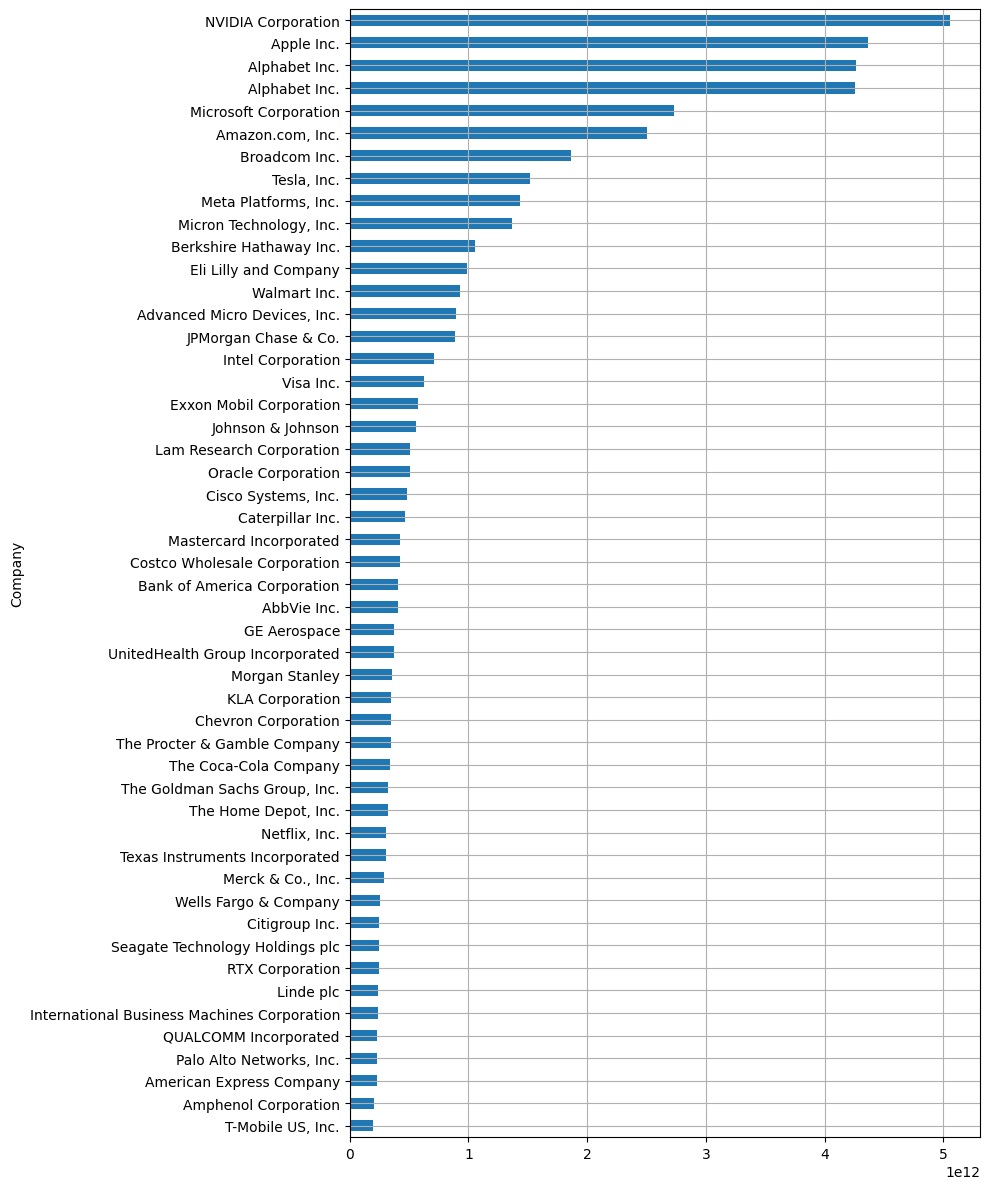

In [26]:
sortandgraph(sp500_data,50,["Company","MarketCap"],"Company","MarketCap",(10,12),"barh")

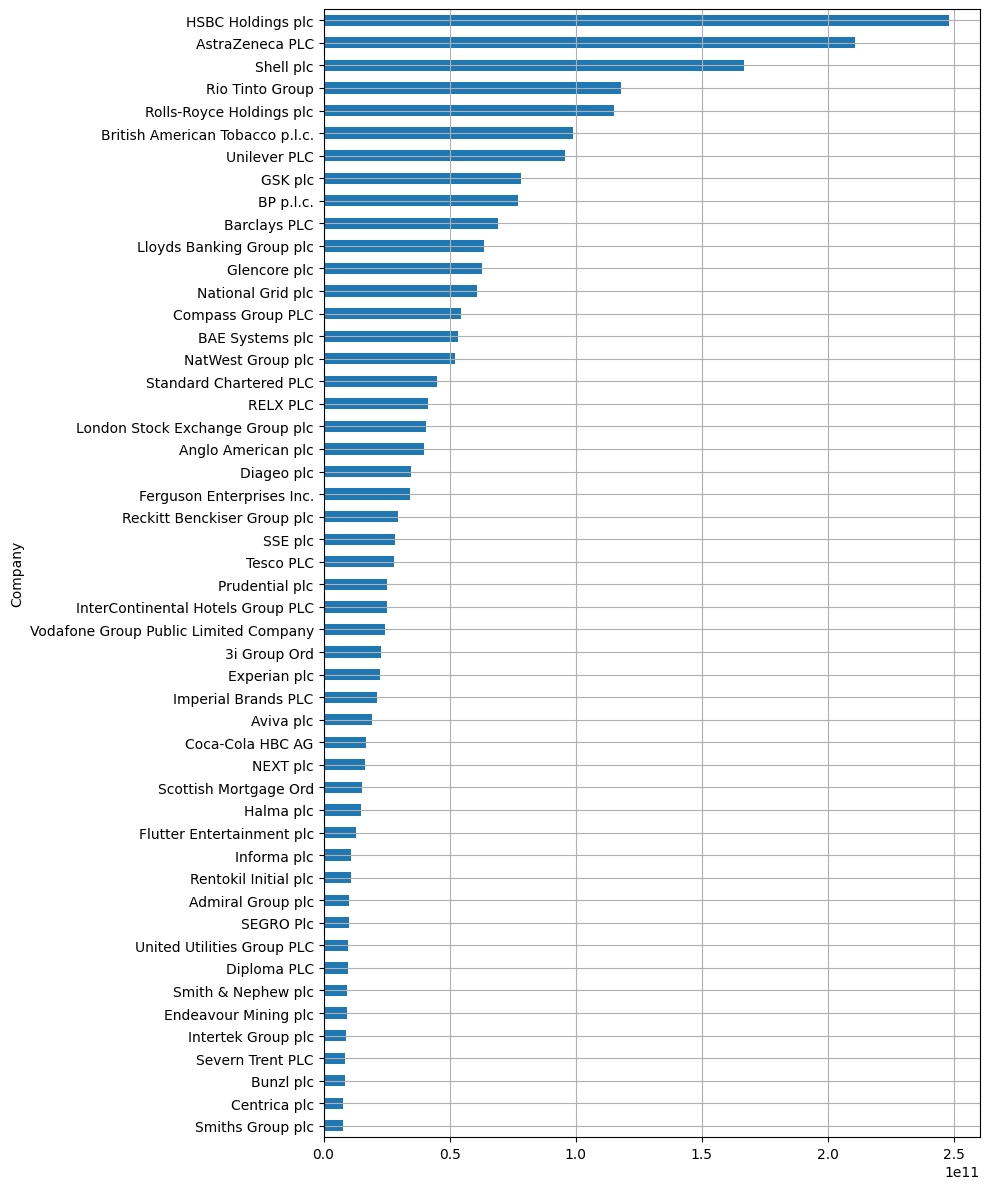

In [27]:
sortandgraph(ftse100_data,50,["Company","MarketCap"],"Company","MarketCap",(10,12),"barh")

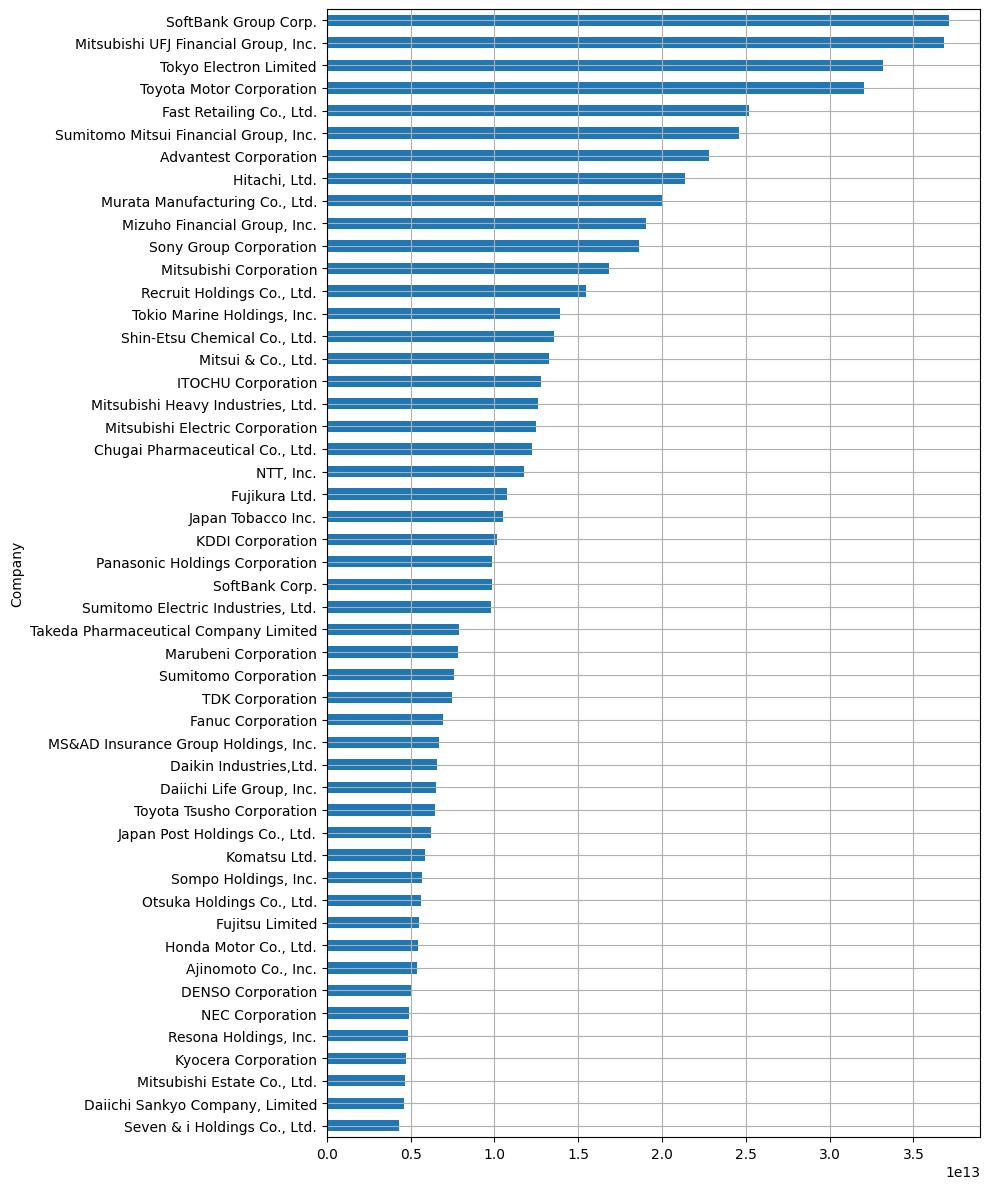

In [28]:
sortandgraph(nikkei225_data,50,["Company","MarketCap"],"Company","MarketCap",(10,12),"barh")

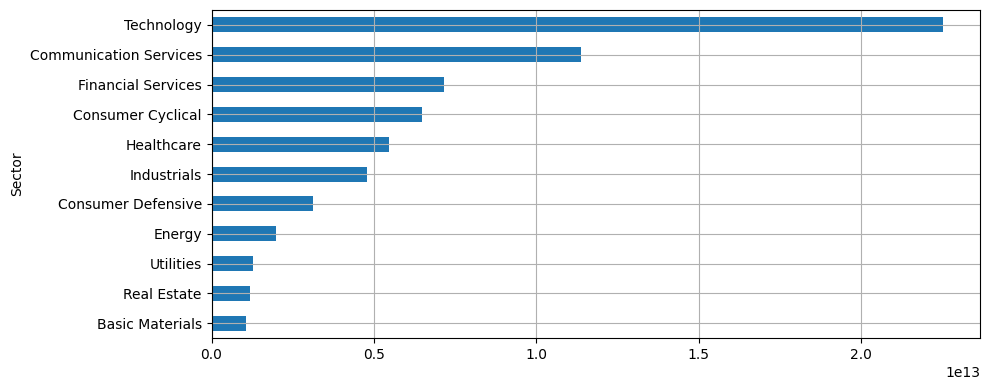

In [29]:
plot_graph(sp500_sector_sum,["Sector","MarketCap"],"Sector","MarketCap",(10,4),"barh")

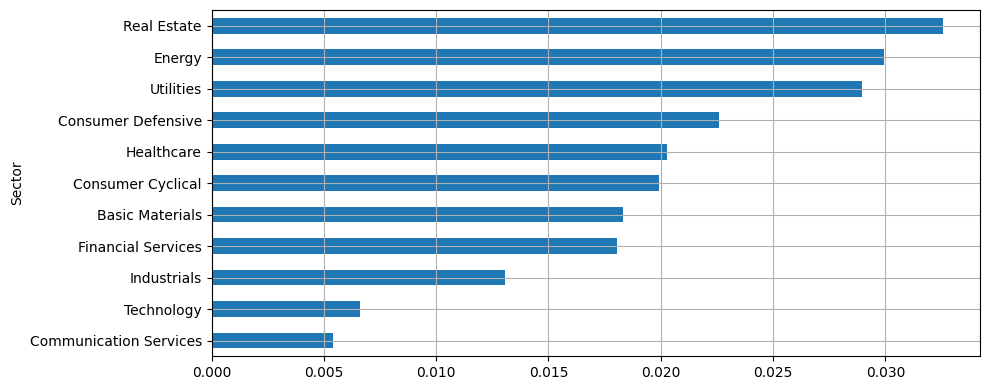

In [30]:
plot_graph(sp500_sector_dividend, ["Sector","DividendRate"],"Sector","DividendRate",(10,4),"barh")

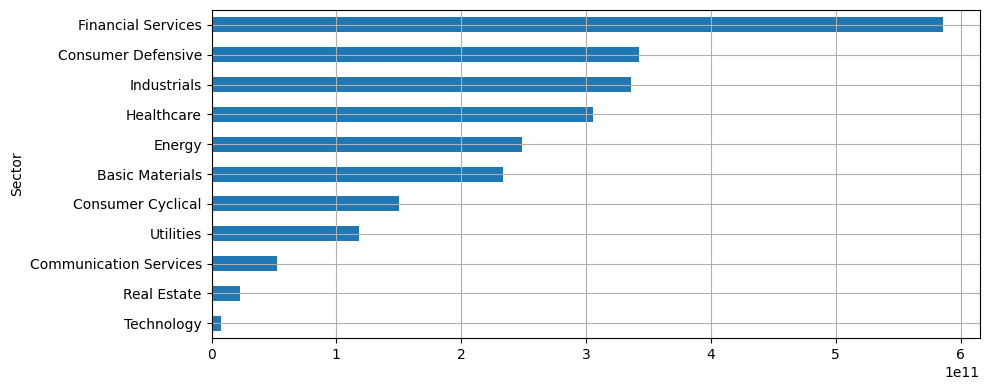

In [31]:
plot_graph(ftse100_sector_sum,["Sector","MarketCap"],"Sector","MarketCap",(10,4),"barh")

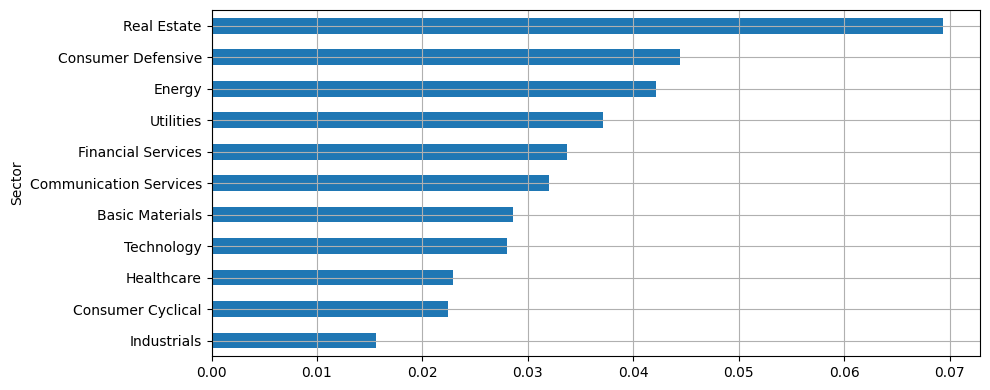

In [32]:
plot_graph(ftse100_sector_dividend, ["Sector","DividendRate"],"Sector","DividendRate",(10,4),"barh")

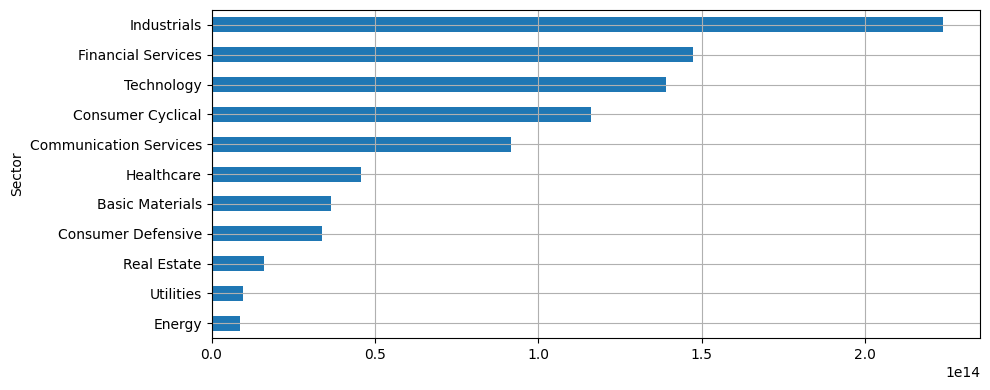

In [33]:
plot_graph(nikkei225_sector_sum,["Sector","MarketCap"],"Sector","MarketCap",(10,4),"barh")

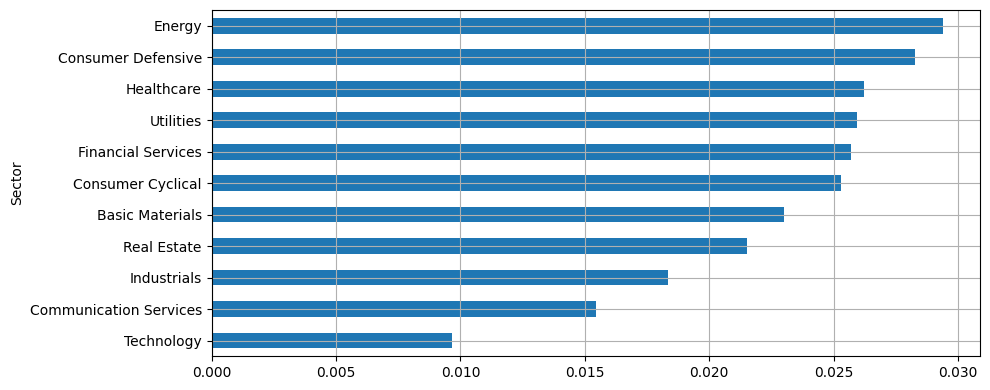

In [34]:
plot_graph(nikkei225_sector_dividend, ["Sector","DividendRate"],"Sector","DividendRate",(10,4),"barh")

### Dashboard

In [35]:
# get latitude and longitude from corporate address information
def gatherAddress(profile_data_path, ticker_list):
                   
    with open(profile_data_path, 'r', encoding='utf-8') as f:
        profile_data = json.load(f)
    
    valid_companies = {}
    
    for ticker in ticker_list:
        if ticker in profile_data and isinstance(profile_data[ticker], dict):
            website = profile_data[ticker].get('website','')
            employee = profile_data[ticker].get('fullTimeEmployees','')
            
            address1 = profile_data[ticker].get('address1','')
            city = profile_data[ticker].get('city','')
            zip_code = profile_data[ticker].get('zip','')
            country = profile_data[ticker].get('country','')
            
            address_parts = [address1, city, zip_code, country]
            valid_parts = []
            
            for p in address_parts:
                if p:
                    valid_parts.append(p)
            full_address = ", ".join(valid_parts)
            
            if full_address:
                            
                geolocator = Nominatim(user_agent="geo_application")
                location = geolocator.geocode(full_address)
                
                if location:
                    valid_companies[ticker] = {
                        "full_address": full_address, 
                        "latitude": location.latitude, 
                        "longitude": location.longitude,
                        "employees": employee,
                        "website": website}
            
            else:
                print(f"{ticker} was not found (full_address missing).")
        else:
            print(f"{ticker} was not found.")          
    
        time.sleep(1)
    
    return valid_companies

In [36]:
azn_location = gatherAddress('ftse100_profile_20260623.json',['AZN.L'])
azn_location

{'AZN.L': {'full_address': '1 Francis Crick Avenue, Cambridge, CB2 0AA, United Kingdom',
  'latitude': 52.175268,
  'longitude': 0.1341117,
  'employees': 96100,
  'website': 'https://www.astrazeneca.com'}}

In [38]:
# sp500_location = gatherAddress('sp500_profile_20260623.json',sp500)

In [ ]:
# ftse100_location = gatherAddress('ftse100_profile_20260623.json',ftse100)

In [ ]:
# nikkei225_location = gatherAddress('nikkei225_profile_20260623.json',nikkei225)

In [5]:
# 1. put latitude,longitude and height data
with open('ftse100_location_20260628.json', 'r', encoding='utf-8') as f:
    ftse100_location = json.load(f)
df_geo_ftse100 = pd.DataFrame.from_dict(ftse100_location, orient='index')

# 2. generate 3D bar on the map
layer = pdk.Layer(
    'ColumnLayer', 
    data=df_geo_ftse100, 
    get_position='[longitude, latitude]',
    get_elevation='employees',
    elevation_scale=0.5,
    radius=1000,
    get_fill_color='[255, 0, 0, 200]',
    pickable=True
)
# 3. determine the place where initial display
view = pdk.ViewState(
    latitude=51.5074,
    longitude=-0.1278,
    zoom=7,
    pitch=45
)

# 4. down load as HTML file
pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip={"text":"website: {website}\n employees:{employees}"},
    map_style='road'
).to_html('ftse100_simple_map.html')

In [6]:
with open('nikkei225_location_20260628.json', 'r', encoding='utf-8') as f:
    nikkei225_location = json.load(f)

df_geo_nikkei225 = pd.DataFrame.from_dict(nikkei225_location, orient='index')

layer = pdk.Layer(
    'ColumnLayer', 
    data=df_geo_nikkei225, 
    get_position='[longitude, latitude]',
    get_elevation='employees',
    elevation_scale=0.5,
    radius=1000,
    get_fill_color='[255, 0, 0, 200]',
    pickable=True
)
view = pdk.ViewState(
    latitude=35.6895,
    longitude=139.6917,
    zoom=7,
    pitch=45
)

pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip={"text":"website: {website}\n employees:{employees}"},
    map_style='road'
).to_html('nikkei225_simple_map.html')

In [7]:
with open('sp500_location_20260628.json', 'r', encoding='utf-8') as f:
    sp500_location = json.load(f)

df_geo_sp500 = pd.DataFrame.from_dict(sp500_location, orient='index')

layer = pdk.Layer(
    'ColumnLayer', 
    data=df_geo_sp500, 
    get_position='[longitude, latitude]',
    get_elevation='employees',
    elevation_scale=0.5,
    radius=1000,
    get_fill_color='[255, 0, 0, 200]',
    pickable=True
)
view = pdk.ViewState(
    latitude=40.7128,
    longitude=-74.0060,
    zoom=6,
    pitch=45
)

pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip={"text":"website: {website}\n employees:{employees}"},
    map_style='road'
).to_html('sp500_simple_map.html')